# Hero FinCorp Loan Portfolio Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
customers = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')
applications = pd.read_csv('applications.csv')
branches = pd.read_csv('branches.csv')
defaults = pd.read_csv('defaults.csv')
loans = pd.read_csv('loans.csv')

print("Data Loaded")

Data Loaded


/tmp/ipykernel_5984/3866752812.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv('applications.csv')


## Data Cleaning

In [3]:
# Convert dates
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

# Handle missing values
applications.fillna({'Rejection_Reason': 'None'}, inplace=True)
defaults.fillna(0, inplace=True)

# Remove duplicates
for df_ in [customers, transactions, applications, defaults, loans]:
    df_.drop_duplicates(inplace=True)

print("Cleaning done")

Cleaning done


## Data Merging

In [4]:
# Merge loans + customers
df = loans.merge(customers, on='Customer_ID', how='left')

# Merge defaults
df = df.merge(defaults[['Loan_ID','Default_Amount','Recovery_Amount']], on='Loan_ID', how='left')

# Create features
df['Default_Flag'] = df['Loan_ID'].isin(defaults['Loan_ID']).astype(int)
df['Recovery_Rate'] = df['Recovery_Amount'] / df['Default_Amount']

# Fill NA safely
df['Recovery_Rate'] = df['Recovery_Rate'].fillna(0)

print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender',
       'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score',
       'Region', 'Account_Tenure', 'Relationship_Manager_ID', 'Default_Amount',
       'Recovery_Amount', 'Default_Flag', 'Recovery_Rate'],
      dtype='object')


## Descriptive Analysis

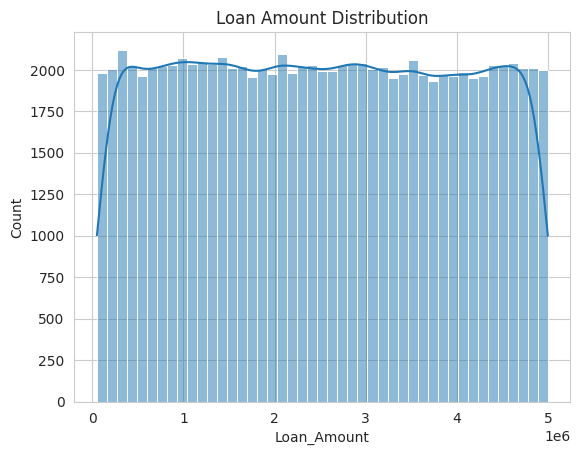

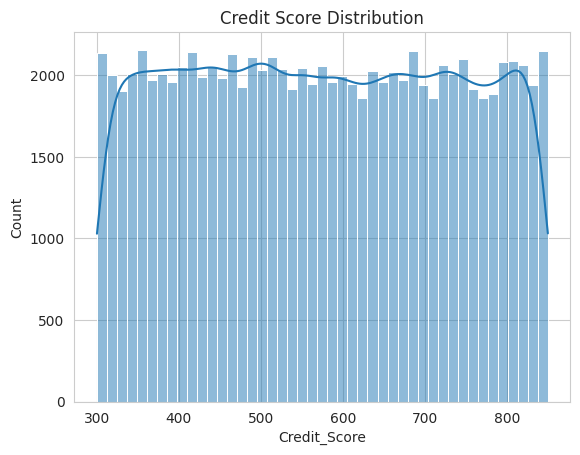

In [5]:
plt.figure()
sns.histplot(df['Loan_Amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

plt.figure()
sns.histplot(df['Credit_Score'], kde=True)
plt.title("Credit Score Distribution")
plt.show()

## Default Risk Analysis

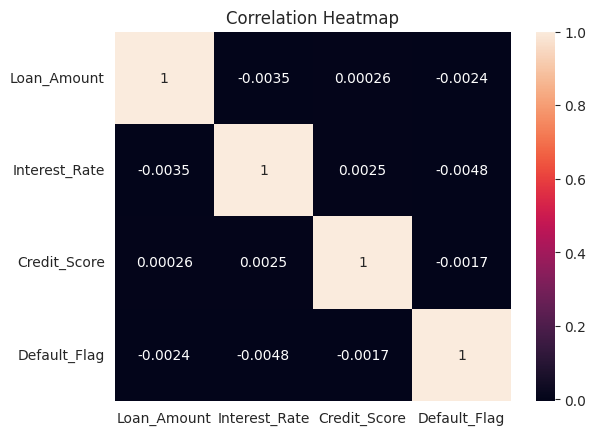

In [6]:
corr = df[['Loan_Amount','Interest_Rate','Credit_Score','Default_Flag']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Regional Performance

In [7]:
region_perf = df.groupby('Region').agg({
    'Loan_ID':'count',
    'Loan_Amount':'sum',
    'Default_Flag':'mean'
}).reset_index()

region_perf.rename(columns={
    'Loan_ID':'Total_Loans',
    'Loan_Amount':'Total_Disbursement',
    'Default_Flag':'Default_Rate'
}, inplace=True)

region_perf

,Region,Total_Loans,Total_Disbursement,Default_Rate
0,Central,14925,37427008869,0.100436
1,East,15384,38618645355,0.093019
2,North,15117,38164304556,0.093669
3,Northeast,15015,37659738379,0.100100
4,South,15030,37942392719,0.105256
5,West,14990,37846687801,0.104670


## Customer Segmentation

In [8]:
df['Income_Segment'] = pd.qcut(df['Annual_Income'], 3, labels=['Low','Medium','High'])
df['Credit_Segment'] = pd.qcut(df['Credit_Score'], 3, labels=['Poor','Average','Good'])

segment = df.groupby(['Income_Segment','Credit_Segment'])['Default_Flag'].mean().reset_index()
segment

/tmp/ipykernel_5984/2490166802.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment = df.groupby(['Income_Segment','Credit_Segment'])['Default_Flag'].mean().reset_index()


,Income_Segment,Credit_Segment,Default_Flag
0,Low,Poor,0.104296
1,Low,Average,0.096633
2,Low,Good,0.099488
3,Medium,Poor,0.101365
4,Medium,Average,0.102181
5,Medium,Good,0.101607
6,High,Poor,0.099225
7,High,Average,0.092977
8,High,Good,0.097615


## Profitability Analysis

In [9]:
# Interest income
df['Interest_Income'] = df['Loan_Amount'] * df['Interest_Rate'] * df['Loan_Term'] / 12

# Loss from defaults
df['Loss'] = df['Default_Amount'] - df['Recovery_Amount']
df['Loss'] = df['Loss'].fillna(0)

# Net Profit
df['Net_Profit'] = df['Interest_Income'] - df['Loss']

profit_region = df.groupby('Region')['Net_Profit'].sum().reset_index()
profit_region

,Region,Net_Profit
0,Central,1.241498e+12
1,East,1.270626e+12
2,North,1.269284e+12
3,Northeast,1.254958e+12
4,South,1.245157e+12
5,West,1.261330e+12


## Time Series Analysis

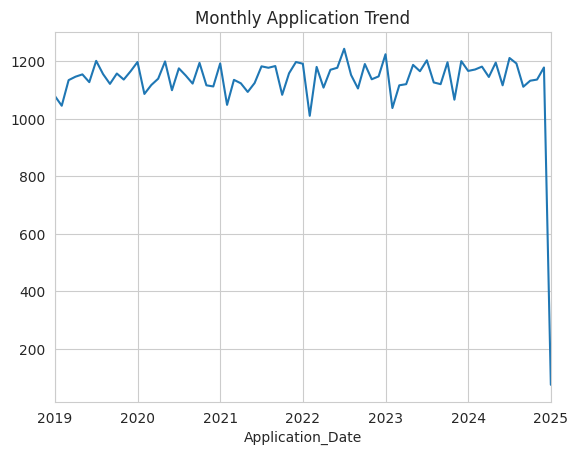

In [10]:
monthly_apps = applications.groupby(applications['Application_Date'].dt.to_period('M')).size()

plt.figure()
monthly_apps.plot()
plt.title("Monthly Application Trend")
plt.show()

## Customer Behavior Analysis

In [11]:
behavior = df.groupby('Customer_ID')['Default_Flag'].sum().reset_index()

def classify(x):
    if x == 0:
        return "Safe"
    elif x == 1:
        return "Occasional Defaulter"
    else:
        return "Risky"

behavior['Segment'] = behavior['Default_Flag'].apply(classify)
behavior.head()

,Customer_ID,Default_Flag,Segment
0,C000003,0,Safe
1,C000004,0,Safe
2,C000005,0,Safe
3,C000007,0,Safe
4,C000008,0,Safe


Key Insights & Recommendations

- Lower credit score strongly correlates with higher default risk  
- Certain regions show higher default rates -> focus risk controls  
- High EMI / Loan amount combinations increase default probability  
- Profitability depends heavily on recovery efficiency  

Recommendations:
- Strengthen credit score-based approval filters  
- Improve recovery mechanisms in high-default regions  
- Monitor high-risk segments proactively  
- Optimize interest rates vs risk segments  
